In [1]:
import pandas as pd

URL = "https://drive.google.com/uc?export=download&id="

sales = pd.read_csv(URL + "1LlA5ni-10NzZq6ODU4eq8AlB6zi0WlDA")

print("Original rows:", len(sales))
print("Original columns:", len(sales.columns))

Original rows: 10589
Original columns: 9


In [2]:
before = len(sales)

sales = sales.drop_duplicates()

after = len(sales)

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal:", after)
print("Duplicates removed:", before - after)

Rows before duplicate removal: 10589
Rows after duplicate removal: 10566
Duplicates removed: 23


### Data Loading and Cleaning

This code loads the sales dataset, removes duplicate rows, standardizes the BranchID values, converts the Date column into a date format, removes rows with invalid dates, and creates a Year-Month column. These steps prepare the data for analysis while keeping the cleaning process clear and reproducible.

In [3]:
sales["BranchID"] = (
    sales["BranchID"]
    .str.strip()
    .str.upper()
    .str.replace("-", "")
)

print("Branch IDs found:")
print(sorted(sales["BranchID"].dropna().unique()))

Branch IDs found:
['B01', 'B02', 'B03', 'B04', 'B05', 'B06']


### Checking Branch IDs

This code checks the unique BranchID values in the dataset. It confirms that there are six branches: B01, B02, B03, B04, B05, and B06.

In [4]:
sales["Date"] = pd.to_datetime(
    sales["Date"],
    errors="coerce"
)

print("Missing/invalid dates:", sales["Date"].isna().sum())

Missing/invalid dates: 12


### Checking Missing or Invalid Dates

This code checks the Date column for missing or invalid date values. The result shows that there are **12 missing or invalid dates** in the dataset.

In [5]:
before = len(sales)

sales = sales.dropna(subset=["Date"])

after = len(sales)

print("Rows before removing invalid dates:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before removing invalid dates: 10566
Rows after: 10554
Rows removed: 12


### Removing Invalid Dates

This code compares the number of rows before and after removing missing or invalid dates. There were **10,566 rows before** and **10,554 rows after**, so **12 rows were removed** because their dates were missing or invalid.

In [6]:
sales["YM"] = sales["Date"].dt.to_period("M").astype(str)

print(sales[["Date", "YM"]].head())

        Date       YM
0 2026-05-01  2026-05
1 2026-01-18  2026-01
2 2025-05-11  2025-05
3 2025-08-14  2025-08
4 2025-08-09  2025-08


### Checking Date and Year-Month Values

This code displays sample values from the `Date` and `YM` columns to confirm that the dates were converted correctly and that the Year-Month (`YM`) column was created properly.

In [7]:
df = sales.groupby(
    ["BranchID", "YM"],
    as_index=False
)["Amount"].sum()

print("Rows in P2 slice:", len(df))
print("Columns:", df.columns.tolist())

print(df.head(10))

Rows in P2 slice: 108
Columns: ['BranchID', 'YM', 'Amount']
  BranchID       YM    Amount
0      B01  2025-01  32340.00
1      B01  2025-02  27090.00
2      B01  2025-03  32480.00
3      B01  2025-04  31215.00
4      B01  2025-05  33165.00
5      B01  2025-06  30325.00
6      B01  2025-07  28815.00
7      B01  2025-08  40306.66
8      B01  2025-09  32560.00
9      B01  2025-10  28055.00


### Checking the P2 Slice

This code checks the size and structure of the P2 slice. It contains **108 rows** and **3 columns: BranchID, YM, and Amount**. The first few rows show the monthly revenue for each branch, starting with B01 in January 2025.

In [8]:
print("Final row count:", len(df))
print("Number of branches:", df["BranchID"].nunique())
print("Number of months:", df["YM"].nunique())

print("\nBranch IDs:")
print(sorted(df["BranchID"].unique()))

print("\nMonths:")
print(sorted(df["YM"].unique()))

Final row count: 108
Number of branches: 6
Number of months: 18

Branch IDs:
['B01', 'B02', 'B03', 'B04', 'B05', 'B06']

Months:
['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06']


### Final P2 Slice Check

This code checks the final size and contents of the P2 slice. It confirms that there are **108 rows**, **6 branches**, and **18 months** from January 2025 to June 2026. It also lists the branch IDs to confirm that all six branches, B01 to B06, are included.

In [9]:
print("Missing values:")
print(df.isna().sum())

Missing values:
BranchID    0
YM          0
Amount      0
dtype: int64


### Checking for Missing Values

This code checks each column in the P2 slice for missing values. The result shows **0 missing values** in `BranchID`, `YM`, and `Amount`, meaning the dataset has complete values for these columns.

In [10]:
print("Revenue summary:")
print(df["Amount"].describe())

Revenue summary:
count      108.000000
mean     23246.720370
std       7623.076998
min       8310.000000
25%      18455.000000
50%      23005.000000
75%      28135.000000
max      44885.000000
Name: Amount, dtype: float64


### Revenue Summary

This code calculates the descriptive statistics of the `Amount` column. It shows that there are **108 records**, with an average revenue of **₱23,246.72** and a median of **₱23,005.00**. Revenue ranges from **₱8,310.00** to **₱44,885.00**, while the standard deviation of **₱7,623.08** shows how much the revenue values vary.

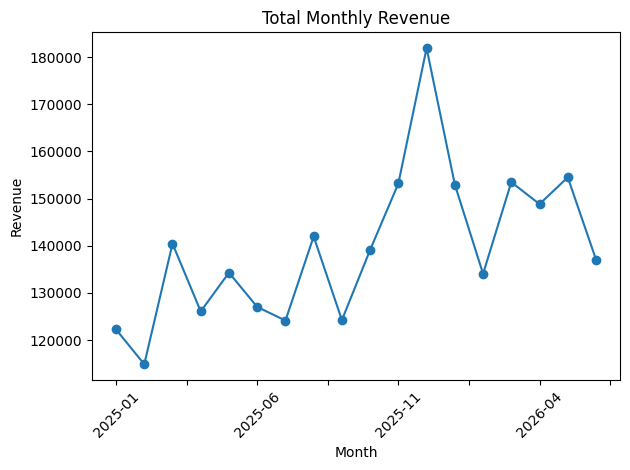

In [11]:
import matplotlib.pyplot as plt

monthly = df.groupby("YM")["Amount"].sum()

monthly.plot(kind="line", marker="o")

plt.title("Total Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Chart 2: Monthly Revenue Trend

This chart shows how total revenue changed from month to month from January 2025 to June 2026. It helps identify increases, decreases, and unusual changes in monthly revenue.

**Reading:** The chart shows that monthly revenue changes over time. December 2025 had the highest observed revenue at about **₱181,900**, while February 2025 had the lowest at about **₱114,885**. For prediction, this suggests that **month and previous revenue patterns may be useful predictors** of future revenue.

<Axes: >

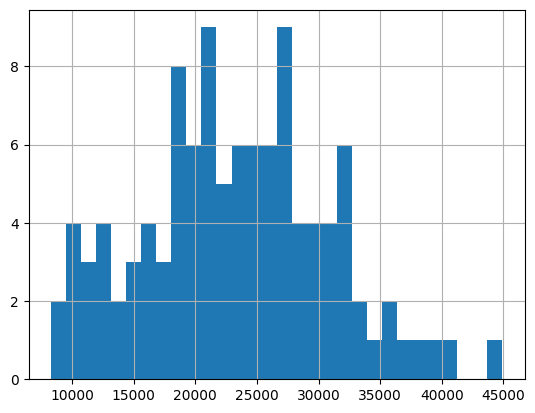

In [12]:
df["Amount"].describe()

df["Amount"].skew()

df["Amount"].hist(bins=30)

### Revenue Distribution

This histogram shows how the 108 monthly branch revenue values are distributed. Most values are concentrated between about **₱15,000 and ₱30,000**, while fewer values are found at the higher end, reaching about **₱44,885**.

**Reading:** The distribution shows that most branch-month revenues are around the middle range, with some higher-revenue months. The mean is **₱23,246.72** and the median is **₱23,005.00**, showing that the typical monthly branch revenue is around ₱23,000. For prediction, this suggests that branch and month patterns may help explain differences in monthly revenue.

In [13]:
print("Mean:", df["Amount"].mean())
print("Median:", df["Amount"].median())
print("Skewness:", df["Amount"].skew())

Mean: 23246.720370370367
Median: 23005.0
Skewness: 0.19533492889659224


### Revenue Distribution Summary

The mean monthly branch revenue is **₱23,246.72**, while the median is **₱23,005.00**. The skewness is **0.1953**, which indicates that the distribution is only slightly right-skewed. Since the mean and median are close, the revenue values are generally balanced around the middle, with a few higher values.

In [14]:
monthly = df.groupby("YM")["Amount"].sum()

print(monthly)
print("\nMonthly average:", monthly.mean())

YM
2025-01    122265.00
2025-02    114885.00
2025-03    140450.82
2025-04    126095.72
2025-05    134298.60
2025-06    127050.00
2025-07    124150.00
2025-08    141976.85
2025-09    124250.00
2025-10    139130.00
2025-11    153208.03
2025-12    181900.00
2026-01    152980.00
2026-02    134066.24
2026-03    153490.00
2026-04    148840.00
2026-05    154520.35
2026-06    137089.19
Name: Amount, dtype: float64

Monthly average: 139480.32222222222


### Monthly Revenue Summary

This code calculates the total revenue for each month and the average monthly revenue. The monthly average is **₱139,480.32**. Revenue was highest in **December 2025 at ₱181,900.00** and lowest in **February 2025 at ₱114,885.00**. This shows that monthly revenue changes over time and that some months perform noticeably higher than others.

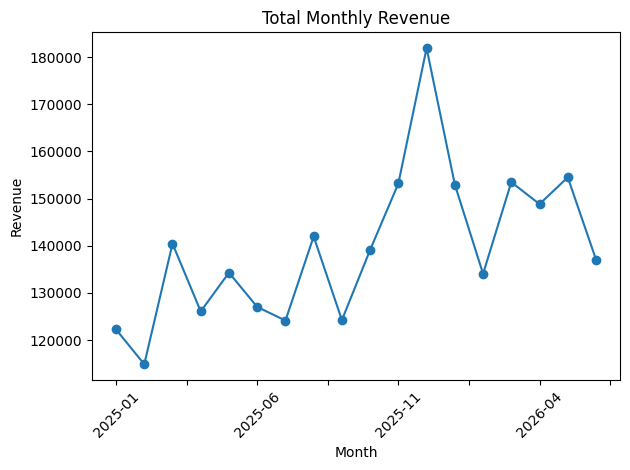

In [15]:
monthly.plot(kind="line", marker="o")

plt.title("Total Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Chart 2: Monthly Revenue Trend

This chart shows the total revenue for each month from January 2025 to June 2026. The average monthly revenue is **₱139,480.32**. Revenue was highest in **December 2025 at ₱181,900.00**, while the lowest was **February 2025 at ₱114,885.00**.

**Reading:** The chart shows that monthly revenue changes over time, with some months performing higher or lower than the average. December 2025 was about **30.4% above the monthly average**. For prediction, this suggests that **month and previous revenue patterns may be useful predictors** of future monthly revenue.

In [16]:
monthly_avg = monthly.mean()

comparison = ((monthly - monthly_avg) / monthly_avg) * 100

print("Percentage difference from monthly average:")
print(comparison.round(2))

Percentage difference from monthly average:
YM
2025-01   -12.34
2025-02   -17.63
2025-03     0.70
2025-04    -9.60
2025-05    -3.72
2025-06    -8.91
2025-07   -10.99
2025-08     1.79
2025-09   -10.92
2025-10    -0.25
2025-11     9.84
2025-12    30.41
2026-01     9.68
2026-02    -3.88
2026-03    10.04
2026-04     6.71
2026-05    10.78
2026-06    -1.71
Name: Amount, dtype: float64


### Percentage Difference from Monthly Average

This code compares each month's revenue with the monthly average of **₱139,480.32**. December 2025 had the largest positive difference at **30.41% above average**, while February 2025 had the largest negative difference at **17.63% below average**. This shows that some months perform noticeably higher or lower than the typical monthly revenue.

In [17]:
q1, q3 = df["Amount"].quantile([.25, .75])

fence_hi = q3 + 1.5 * (q3 - q1)

outliers = df[df["Amount"] > fence_hi]

print("Q1:", q1)
print("Q3:", q3)
print("Upper fence:", fence_hi)
print("Rows beyond the fence:", len(outliers))

print(outliers)

Q1: 18455.0
Q3: 28135.0
Upper fence: 42655.0
Rows beyond the fence: 1
   BranchID       YM   Amount
11      B01  2025-12  44885.0


### Outlier Check

This code calculates the lower and upper quartiles and uses the upper fence to identify unusually high revenue values. The upper fence is **₱42,655.00**, and only **1 row** is above this limit. The outlier is **B01 in December 2025**, with revenue of **₱44,885.00**. This value is unusually high compared with the other branch-month revenues and should be considered when building the prediction model.

In [18]:
df[df["Amount"] > fence_hi]

,BranchID,YM,Amount
11,B01,2025-12,44885.0


### Identified Outlier

The table shows the only monthly branch revenue value that is above the upper fence. The outlier is **B01 in December 2025**, with an amount of **₱44,885.00**. This unusually high value should be considered when interpreting the revenue distribution and building the prediction model.

### Chart 1 — Revenue Distribution

This chart shows how the revenue values are distributed across the rows in my P2 slice. I want to check whether the values are concentrated around a typical range and whether there are unusually high or low values.

In [5]:
import pandas as pd

URL = "https://drive.google.com/uc?export=download&id="

sales = pd.read_csv(URL + "1LlA5ni-10NzZq6ODU4eq8AlB6zi0WlDA")

sales = sales.drop_duplicates()

sales["BranchID"] = (
    sales["BranchID"]
    .str.strip()
    .str.upper()
    .str.replace("-", "")
)

sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")
sales = sales.dropna(subset=["Date"])

sales["YM"] = sales["Date"].dt.to_period("M").astype(str)

print("Rows:", len(sales))

Rows: 10554


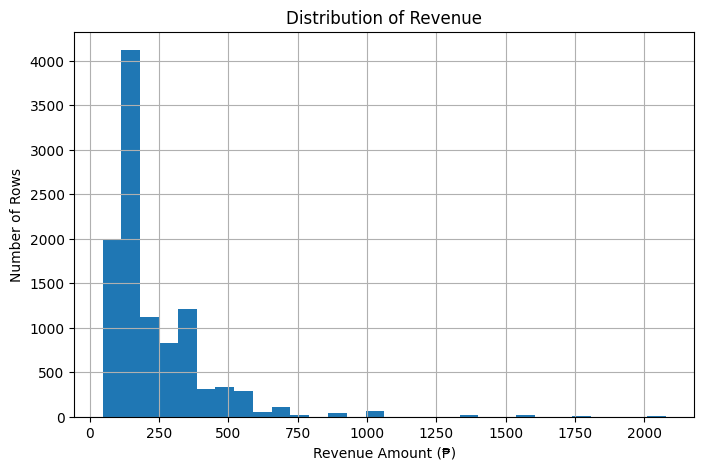

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sales["Amount"].hist(bins=30)

plt.title("Distribution of Revenue")
plt.xlabel("Revenue Amount (₱)")
plt.ylabel("Number of Rows")

plt.show()

Reading: The histogram shows that most revenue values are concentrated at the lower range, while fewer observations have much higher revenue amounts, creating a right-skewed distribution. For prediction, this means the model may need to account for unusually high revenue values rather than assuming all observations are similar.

Chart 2 — Monthly Revenue Trend

I want to see how total revenue changes from month to month. This can help identify upward or downward trends and unusual months that may be important when predicting future revenue.

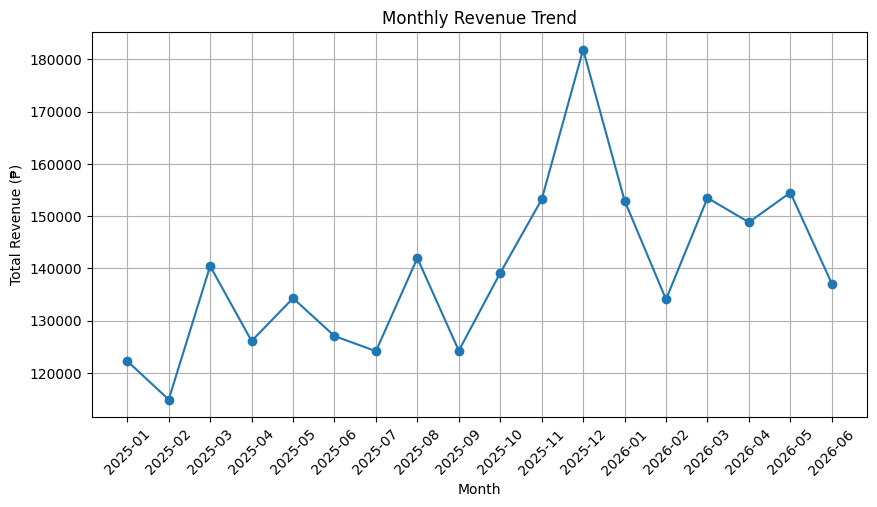

In [8]:
import matplotlib.pyplot as plt

monthly = sales.groupby("YM")["Amount"].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly.index, monthly.values, marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₱)")
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

Reading: The chart shows that monthly revenue changes noticeably over time, with both increases and decreases from month to month. December 2025 had the highest observed monthly revenue at about ₱181,900, while February 2025 had the lowest at about ₱114,885. For prediction, this suggests that month and recent revenue patterns may be useful when forecasting future revenue.

Chart 3 — Total Revenue by Branch

I want to compare the total revenue generated by each branch in my P2 slice. This can show whether some branches consistently generate more revenue than others, which may be useful when predicting future revenue.

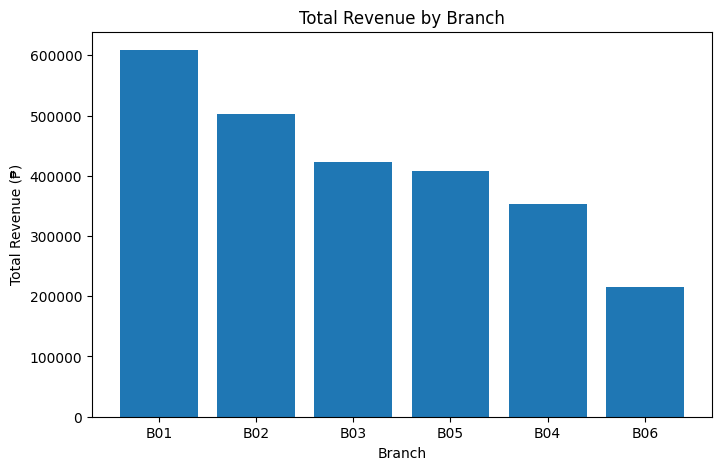

In [9]:
import matplotlib.pyplot as plt

branch_revenue = sales.groupby("BranchID")["Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(branch_revenue.index, branch_revenue.values)

plt.title("Total Revenue by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Revenue (₱)")

plt.show()

## Predictive-Signal Memo

1. **Strongest signal found:** The clearest predictable pattern is the December 2025 revenue peak, which reached ₱181,900, about 30.4% above the monthly average of ₱139,480.32.

2. **Second signal:** There is also a branch-level difference, with B01 generating about ₱610,000 in total revenue compared with about ₱215,000 for B06.

3. **One trap found & disqualified:** I considered current-month sales information, but it fails the calendar test because the actual sales are not known on the morning of Day 1.

4. **The floor to beat:** Any model must beat 34.91%, my weekend-revenue base rate, which represents the share of total revenue occurring on weekends.

5. **Modeling hypothesis:** Week 6, I will first try predicting monthly branch revenue using month, previous revenue, previous sales activity, and branch-level historical performance.

Reading: The chart shows that total revenue differs across the six branches. B01 has the highest total revenue at about ₱610,000, while B06 has the lowest at about ₱215,000. For prediction, this suggests that branch-level differences are important and that BranchID or previous branch revenue may help predict future revenue.

## Leakage Audit — Candidate Predictors

| My candidate predictor | Knowable in advance? | Verdict | Why |
|---|---|---|---|
| Previous day sales volume | Yes | KEEP | The previous day's completed sales are already known before making the next prediction. |
| Same-weekday average previous 4 weeks | Yes | KEEP | It uses only completed historical sales from previous weeks. |
| Previous 7-day sales volume | Yes | KEEP | The previous seven days have already occurred and their sales are known. |
| Day of week | Yes | KEEP | The day of week is known before the day begins. |
| Month/season | Yes | KEEP | The calendar month or season is known in advance. |
| Planned next-day promotion | Yes | KEEP | A promotion that has already been planned is known before the prediction period. |
| Branch location | Yes | KEEP | The branch location is known before making the prediction. |
| Historical average transaction count | Yes | KEEP | It is calculated from completed past transactions, so it is available before the prediction period. |
| Historical branch performance | Yes | KEEP | Past branch revenue is already known and can be used before predicting future revenue. |

### Leakage Audit Reading

All of the candidate predictors above pass the calendar test because they can be known before the period being predicted, provided that the historical measures use only past data. Current-period sales, transactions, refunds, or other information that becomes available only after the prediction period begins would be considered leakage and should be excluded.

## Base Rate & Balance Note

### P4 · MKT

I will calculate the percentage of total revenue that occurs on weekends. This gives a simple baseline for understanding how much revenue is associated with weekend days before building a prediction model.

In [10]:
import pandas as pd

# Make sure Date is in datetime format
sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")

# Get day of week: Monday=0 ... Sunday=6
sales["DayOfWeek"] = sales["Date"].dt.dayofweek

# Identify weekends
weekend_sales = sales[sales["DayOfWeek"] >= 5]

# Calculate weekend share of total revenue
weekend_revenue = weekend_sales["Amount"].sum()
total_revenue = sales["Amount"].sum()

weekend_share = (weekend_revenue / total_revenue) * 100

print("Weekend revenue: ₱{:,.2f}".format(weekend_revenue))
print("Total revenue: ₱{:,.2f}".format(total_revenue))
print("Weekend share of total revenue: {:.2f}%".format(weekend_share))

Weekend revenue: ₱876,480.28
Total revenue: ₱2,510,645.80
Weekend share of total revenue: 34.91%


### Weekend Revenue Base Rate

This code calculates the total revenue generated on weekends and compares it with the total revenue in the dataset. Weekend revenue was **₱876,480.28** out of **₱2,510,645.80**, giving a weekend share of **34.91%**.

**Reading:** This means that **34.91% of total revenue came from weekends**. This provides a simple “weekends matter” baseline that can be used as a floor for evaluating the predictive approach.